# Training a Multi-Cell Spatial Contrast (SC) Model

This notebook trains the multi-cell variant of the Spatial Contrast model from [Sridhar et al., 2025](https://doi.org/10.1101/2024.03.05.583449) on marmoset retinal ganglion cell data.

Unlike the single-cell notebook (`training_sc_sridhar_2025.ipynb`), this version trains **all neurons in a session simultaneously** using the core-readout pattern:

- **Core**: `DummyCore` (pass-through)
- **Readout**: `MultiSpatialContrastReadout` containing per-session `SpatialContrastReadout` modules

Each neuron still has frozen STA-derived spatial and temporal filters and **4 learnable parameters** (w, a, b, c), but they are trained jointly.

$$y_n = a_n \cdot \log(1 + \exp(b_n \cdot (\text{imean}_n + w_n \cdot \text{lsc}_n) + c_n))$$

In [1]:
import os

import hydra
import lightning
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

from openretina.data_io.base import compute_data_info
from openretina.data_io.cyclers import LongCycler, ShortCycler
from openretina.modules.losses import CorrelationLoss3d
from openretina.utils.file_utils import get_local_file_path

# Uncomment and change the path below if you want to use a custom cache directory:
os.environ["OPENRETINA_CACHE_DIRECTORY"] = "/mnt/big_storage/openretina_cache/"

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Configuration

Load the Hydra config for the multi-cell SC model. Available configs:
- `sridhar_2025_wn_sc_multicell.yaml` -- white noise dataset
- `sridhar_2025_nm_sc_multicell.yaml` -- natural movie dataset

By default this trains on session `"04"` (set in the `data_io` config's `sessions` field). To train on all sessions, override `cfg.data_io.sessions`.

In [2]:
config_name = "sridhar_2025_wn_sc_multicell.yaml"

with hydra.initialize(config_path="../configs", version_base="1.3"):
    cfg = hydra.compose(config_name=config_name)

# To train on all retinas, uncomment:
# cfg.data_io.sessions = ["01", "02", "04"]

print(f"Sessions: {list(cfg.data_io.sessions)}")
print(f"Input shape: {list(cfg.model.in_shape)}")
print(f"STA dir: {cfg.model.sta_dir}")

Sessions: ['01', '02', '04']
Input shape: [1, 30, 80, 90]
STA dir: https://huggingface.co/datasets/open-retina/open-retina/tree/main/gollisch_lab/sridhar_2025/marmoset/whitenoise/stas


## Load data

On first run, the dataset will be downloaded to the cache directory. We load both stimuli and responses to compute `data_info`, which provides `n_neurons_dict`, `mean_activity_dict`, and `cell_indices` per session.

In [3]:
movies_dict = hydra.utils.call(cfg.data_io.stimuli)
neuron_data_dict = hydra.utils.call(cfg.data_io.responses)

# Filter to only the sessions selected by retina_index / data_io.sessions.
# response_splits_from_pickles loads ALL sessions in response_files;
# we must drop the ones we won't train on so that the model only creates
# readouts (and loads STAs) for the sessions that appear in the dataloader.
selected_sessions = set(cfg.data_io.sessions)
neuron_data_dict = {k: v for k, v in neuron_data_dict.items() if k in selected_sessions}
movies_dict = {k: v for k, v in movies_dict.items() if k in selected_sessions}

data_info = compute_data_info(neuron_data_dict, movies_dict, partial_data_info=cfg.data_io.get("data_info"))

for session_key, n_neurons in data_info["n_neurons_dict"].items():
    cell_indices = data_info["sessions_kwargs"][session_key]["cell_indices"]
    print(f"Session {session_key}: {n_neurons} neurons (cell indices: {cell_indices[:5]}{'...' if len(cell_indices) > 5 else ''})")

Session 01: 233 neurons (cell indices: [0, 2, 3, 4, 8]...)
Session 02: 69 neurons (cell indices: [10, 13, 14, 19, 20]...)
Session 04: 80 neurons (cell indices: [2, 3, 4, 5, 6]...)


In [4]:
dataloaders = hydra.utils.instantiate(
    cfg.dataloader,
    neuron_data_dictionary=neuron_data_dict,
    movies_dictionary=movies_dict,
)

Random seed 1000 has been set.
train idx: [7 6 9 1 2 8 0 3]
val idx: [ 4 10  5]
Random seed 1000 has been set.
train idx: [2 6 5 1 4 9 0 8]
val idx: [7 3]
Random seed 1000 has been set.
train idx: [2 6 5 1 4 9 0 8]
val idx: [7 3]


## Instantiate the model

The model loads STA files for every neuron in each session. The `cell_indices` from `data_info` tell the model which STA files to load (matching the neurons that survived quality-control exclusion in the dataloader).

In [5]:
# Resolve the STA directory to a local path
cfg.model.sta_dir = get_local_file_path(str(cfg.model.sta_dir))
cfg.model.n_neurons_dict = data_info["n_neurons_dict"]

model = hydra.utils.instantiate(cfg.model, data_info=data_info)

total_neurons = sum(data_info["n_neurons_dict"].values())
num_learnable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total neurons: {total_neurons}")
print(f"Learnable parameters: {num_learnable} ({num_learnable // total_neurons} per neuron)")

Total neurons: 382
Learnable parameters: 1528 (4 per neuron)


/home/shash/PycharmProjects/open-retina/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'core' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['core'])`.
/home/shash/PycharmProjects/open-retina/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'readout' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['readout'])`.
/home/shash/PycharmProjects/open-retina/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


### Inspect filters for example neurons

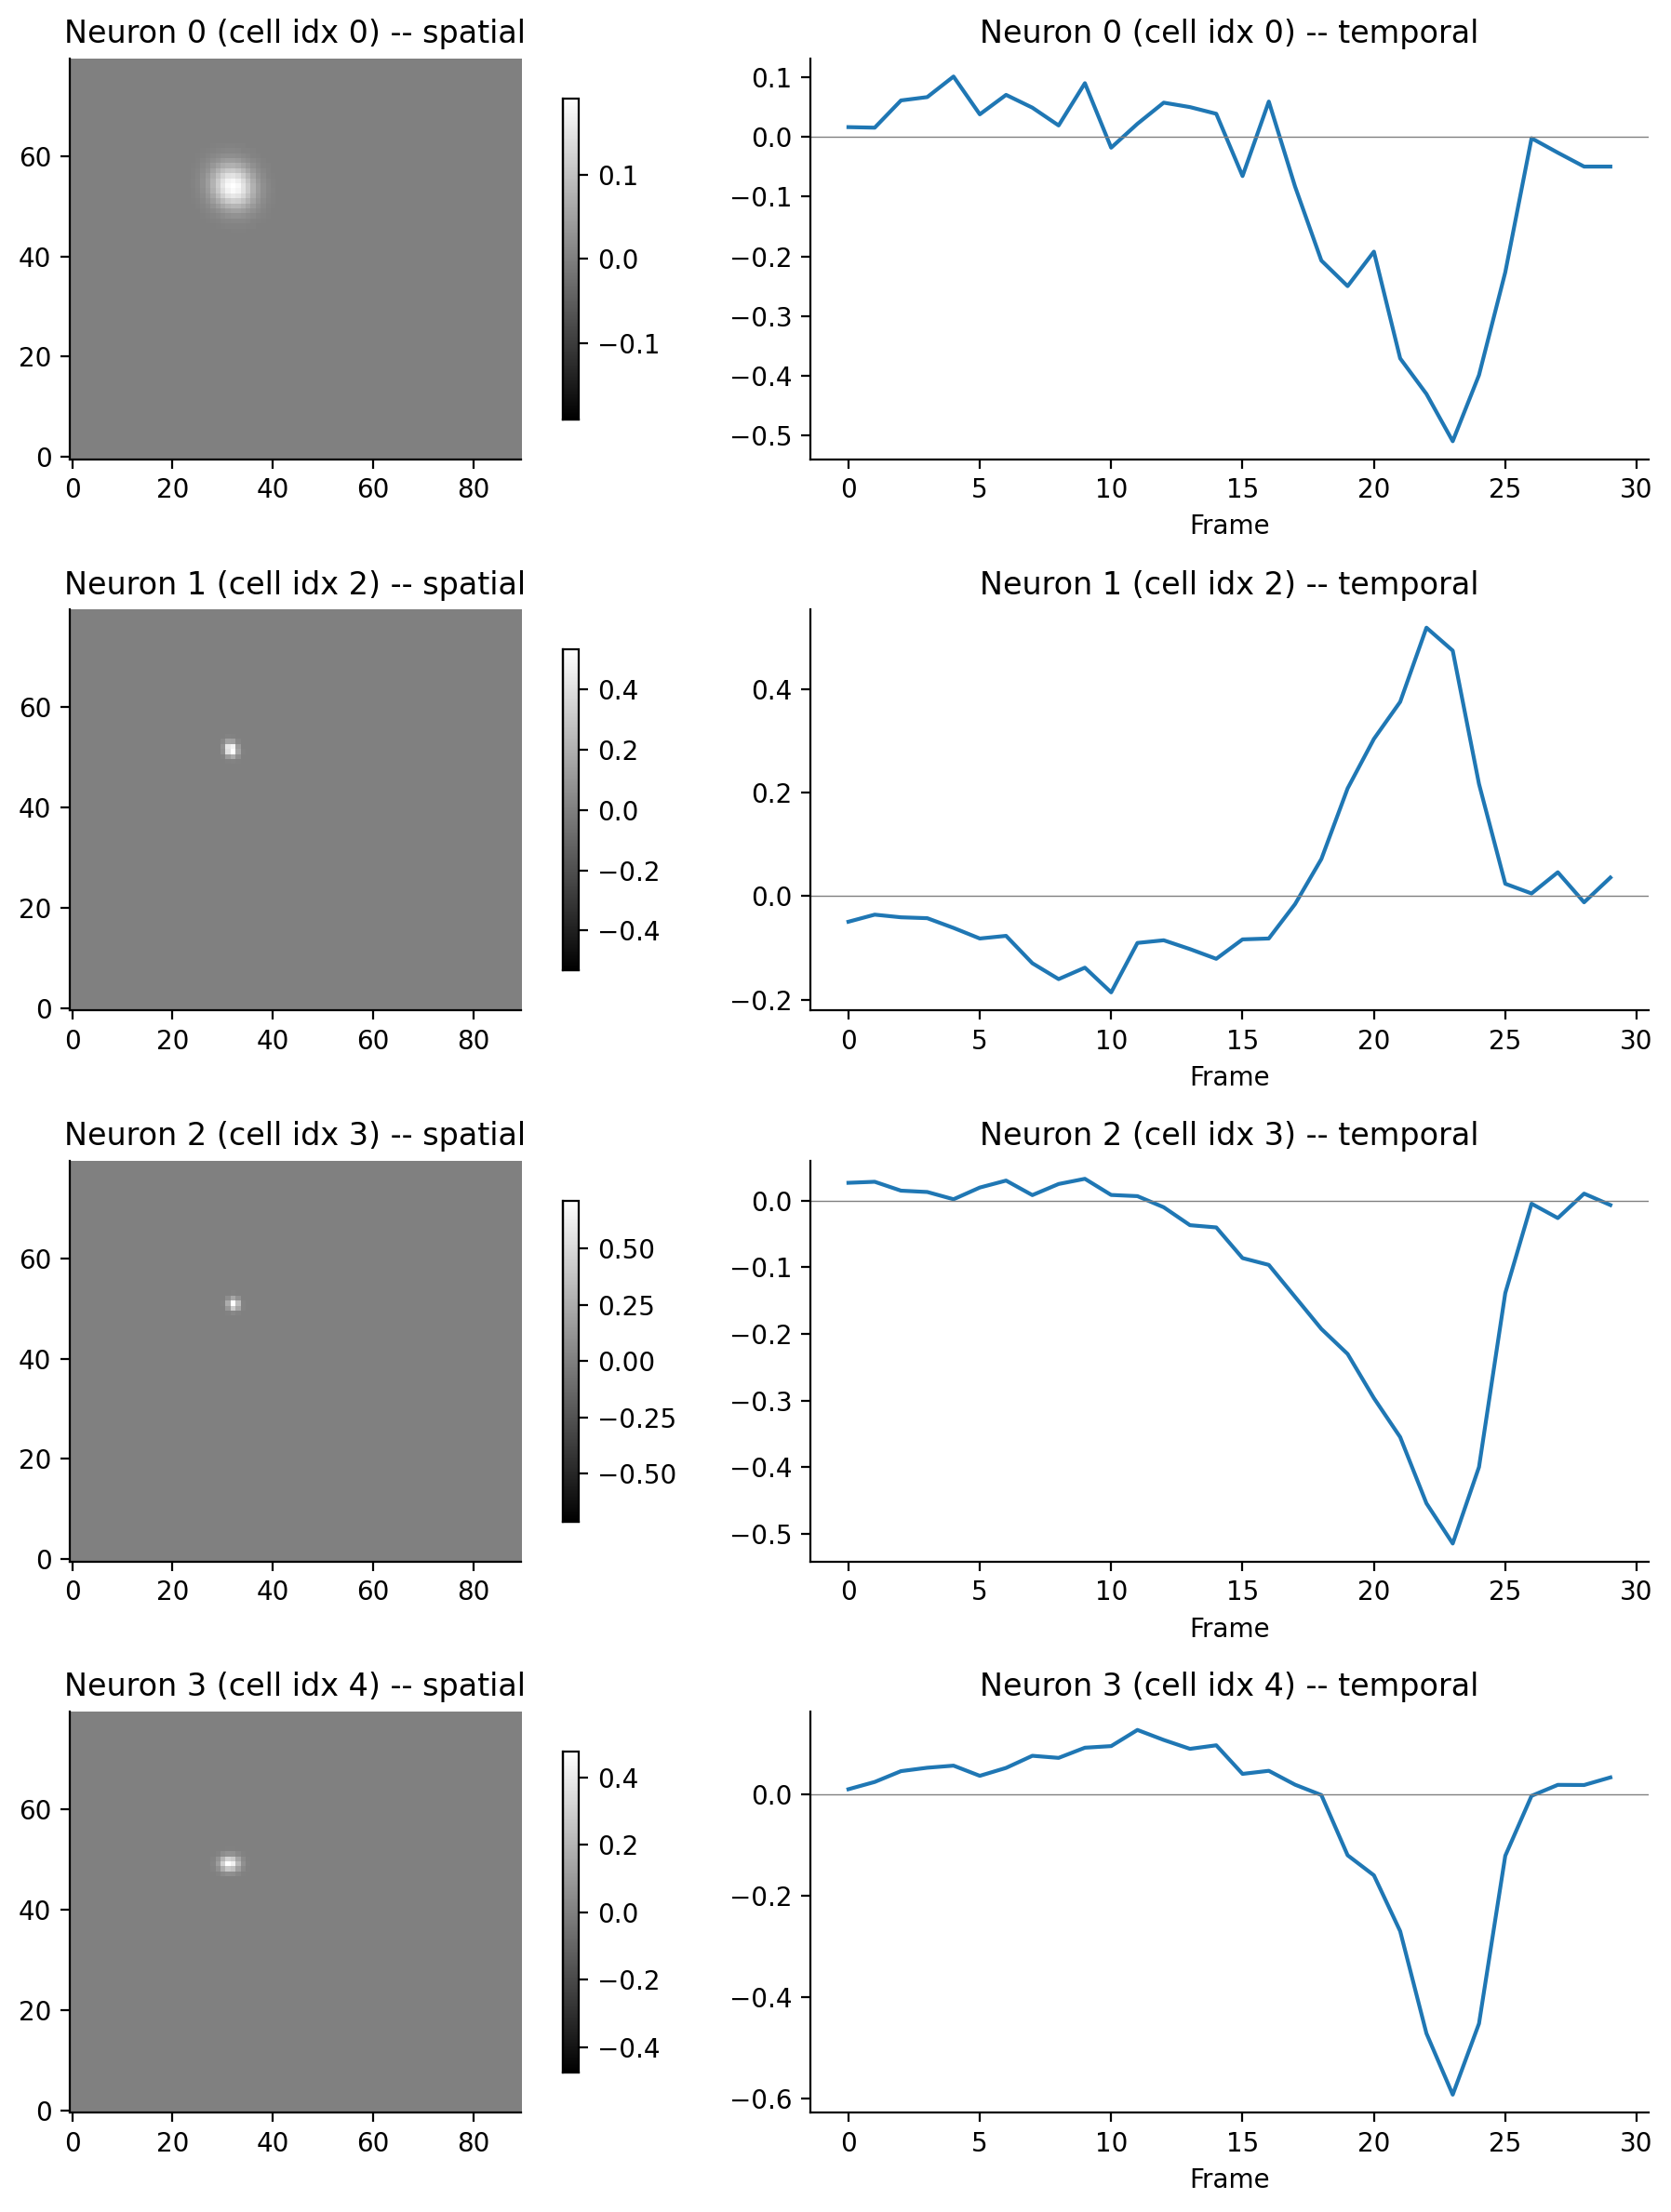

In [6]:
# Show spatial and temporal filters for a few neurons from the first session
session_key = list(data_info["n_neurons_dict"].keys())[0]
readout = model.readout[session_key]

n_examples = min(4, readout.outdims)
fig, axes = plt.subplots(n_examples, 2, figsize=(10, 3 * n_examples))
if n_examples == 1:
    axes = axes[np.newaxis, :]

cell_indices = data_info["sessions_kwargs"][session_key]["cell_indices"]

for i in range(n_examples):
    # Spatial filter
    sf = readout.spatial_filters[i].cpu().numpy()
    vm = np.max(np.abs(sf))
    im = axes[i, 0].imshow(sf, cmap="gray", origin="lower", vmin=-vm, vmax=vm)
    axes[i, 0].set_title(f"Neuron {i} (cell idx {cell_indices[i]}) -- spatial")
    plt.colorbar(im, ax=axes[i, 0], shrink=0.8)

    # Temporal filter
    tf = readout.temporal_filters[i].cpu().numpy()
    axes[i, 1].plot(tf)
    axes[i, 1].axhline(0, color="gray", linewidth=0.5)
    axes[i, 1].set_title(f"Neuron {i} (cell idx {cell_indices[i]}) -- temporal")
    axes[i, 1].set_xlabel("Frame")

sns.despine()
plt.tight_layout()
plt.show()

## Training

In [7]:
os.makedirs(cfg.paths.log_dir, exist_ok=True)

early_stopping = lightning.pytorch.callbacks.EarlyStopping(
    monitor="val_evaluation_loss",
    patience=10,
    mode="max",
    verbose=False,
    min_delta=0.001,
)

lr_monitor = lightning.pytorch.callbacks.LearningRateMonitor(logging_interval="epoch")

model_checkpoint = lightning.pytorch.callbacks.ModelCheckpoint(
    monitor="val_evaluation_loss", mode="max", save_weights_only=False
)

In [8]:
trainer = lightning.Trainer(
    max_epochs=100,
    logger=None,
    callbacks=[early_stopping, lr_monitor, model_checkpoint],
    accelerator="gpu",
    gradient_clip_val=cfg.trainer.gradient_clip_val,
    log_every_n_steps=10,
)

train_loader = LongCycler(dataloaders["train"])
val_loader = ShortCycler(dataloaders["validation"])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type                        | Params | Mode 
------------------------------------------------------------------------
0 | core            | DummyCore                   | 0      | train
1 | readout         | MultiSpatialContrastReadout | 1.9 K  | train
2 | loss            | PoissonLoss3d               | 0      | train
3 | evaluation_loss | CorrelationLoss3d           | 0      | train
------------------------------------------------------------------------
1.5 K     Trainable params
382       Non-trainable params
1.9 K     Total params
0.008     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/shash/PycharmProjects/open-retina/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Results

Inspect the learned parameters and evaluate model performance on held-out test data.

### Learned parameters

In [ ]:
for session_key in model.readout.readout_keys():
    readout = model.readout[session_key]
    print(f"\nSession {session_key} ({readout.outdims} neurons):")
    print(f"  w  (contrast weight): mean={readout.w.data.mean():.4f}, std={readout.w.data.std():.4f}")
    print(f"  a  (output scaling):  mean={readout.nl_a.data.mean():.4f}, std={readout.nl_a.data.std():.4f}")
    print(f"  b  (input gain):      mean={readout.nl_b.data.mean():.4f}, std={readout.nl_b.data.std():.4f}")
    print(f"  c  (offset):          mean={readout.nl_c.data.mean():.4f}, std={readout.nl_c.data.std():.4f}")

### Distribution of contrast weights (w)

The contrast weight *w* controls how much local spatial contrast influences each neuron's response. Higher values indicate stronger contrast sensitivity.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_w = []
for session_key in model.readout.readout_keys():
    w_vals = model.readout[session_key].w.data.cpu().numpy()
    all_w.append(w_vals)
    axes[0].hist(w_vals, bins=30, alpha=0.7, label=f"Session {session_key}")

axes[0].set_xlabel("w (contrast weight)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of contrast weights")
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].legend()

# w vs a scatter
for session_key in model.readout.readout_keys():
    readout = model.readout[session_key]
    axes[1].scatter(
        readout.w.data.cpu().numpy(),
        readout.nl_a.data.cpu().numpy(),
        alpha=0.5,
        s=15,
        label=f"Session {session_key}",
    )
axes[1].set_xlabel("w (contrast weight)")
axes[1].set_ylabel("a (output scaling)")
axes[1].set_title("Contrast weight vs output scaling")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

### Per-neuron correlations on test data

In [ ]:
model.eval()
model.cpu()

per_neuron_corr = CorrelationLoss3d(per_neuron=True, negate=False)
all_correlations = {}

for session_key in dataloaders["test"]:
    test_dataset = dataloaders["test"][session_key].dataset
    with torch.no_grad():
        test_inputs = test_dataset.movies.unsqueeze(1)  # add channel dim
        predictions = model(test_inputs, data_key=session_key)

    targets = test_dataset.responses.unsqueeze(0)  # add batch dim
    # Align temporal dimensions (model output may be shorter)
    t_pred = predictions.shape[1]
    targets_aligned = targets[:, -t_pred:, :]

    corr = per_neuron_corr(predictions, targets_aligned)
    all_correlations[session_key] = corr.numpy()
    print(f"Session {session_key}: mean corr = {corr.mean():.4f}, median = {np.median(corr.numpy()):.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

for session_key, corr in all_correlations.items():
    ax.hist(corr, bins=30, alpha=0.7, label=f"Session {session_key} (n={len(corr)})")

ax.set_xlabel("Correlation")
ax.set_ylabel("Count")
ax.set_title("Per-neuron test correlations")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Predictions vs recorded responses for example neurons

In [ ]:
session_key = list(dataloaders["test"].keys())[0]
test_dataset = dataloaders["test"][session_key].dataset

with torch.no_grad():
    test_inputs = test_dataset.movies.unsqueeze(1)
    predictions = model(test_inputs, data_key=session_key).squeeze(0).numpy()

targets = test_dataset.responses.numpy()
t_pred = predictions.shape[0]
n_cut = targets.shape[0] - t_pred

# Pick neurons with best, median, and worst correlation
corr = all_correlations[session_key]
sorted_idx = np.argsort(corr)
example_indices = [
    sorted_idx[-1],                    # best
    sorted_idx[len(sorted_idx) // 2],  # median
    sorted_idx[0],                     # worst
]
labels = ["Best", "Median", "Worst"]

window = min(500, t_pred)
fig, axes = plt.subplots(len(example_indices), 1, figsize=(14, 3 * len(example_indices)), sharex=True)

cell_indices = data_info["sessions_kwargs"][session_key]["cell_indices"]
for ax, neuron_idx, label in zip(axes, example_indices, labels):
    time_axis = np.arange(n_cut, n_cut + window)
    ax.plot(time_axis, targets[n_cut:n_cut + window, neuron_idx], label="Recorded", alpha=0.7)
    ax.plot(time_axis, predictions[:window, neuron_idx], label="SC model", alpha=0.7)
    ax.set_ylabel("Firing rate [a.u.]")
    ax.set_title(f"{label} neuron (idx {neuron_idx}, cell {cell_indices[neuron_idx]}, r={corr[neuron_idx]:.3f})")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Frame")
sns.despine()
plt.tight_layout()
plt.show()